# Week 10 — Recommendation, Ranking, or Predictive Decision Engine

Este notebook corresponde a la **parte 10** del proyecto y se construye **a partir del K-means trabajado en `clustering.ipynb`**.

La versión está alineada con el contenido de clase:

- **Week 8:** content-based recommendation con representación vectorial, TF-IDF, similitud coseno y métricas top-k.
- **Week 9:** collaborative filtering como método basado en una matriz de interacciones. En este proyecto no se implementa porque el dataset de repositorios no contiene usuarios, ratings, clicks ni playlists.
- **Week 10:** ranking híbrido mediante combinación ponderada de señales, cuidando que todas las señales pertenezcan al mismo universo de ítems: repositorios de GitHub.

Estructura usada:

- **10.2 Baseline system**
- **10.3 Stronger system**
- **10.4 Offline evaluation report**
- **10.5 Error analysis**
- **10.6 Explanation of system type**
- **10.7 Technical expectation**

> Nota metodológica: aquí no se afirma collaborative filtering ni matrix factorization colaborativa, porque no existe una matriz usuario-repositorio. El sistema fuerte es un **hybrid ranking** basado en contenido, PCA, K-means y señales numéricas del mismo catálogo de repositorios.


## Setup previo — cargar datos y reconstruir PCA + K-means

Esta sección no reemplaza el análisis de clustering de Week 7. Solo deja listo el dataset para Week 10 usando la misma lógica técnica: primero se construyen las features, luego se reduce dimensionalidad con PCA y recién después se aplica K-means.

Se usa la misma base limpia:

```text
../data/processed/repos_clean.csv
```

Y se reconstruyen las representaciones necesarias para que el notebook sea reproducible:

- variables numéricas;
- lenguaje principal;
- topics principales;
- PCA con 10 componentes como espacio latente de repositorios;
- K-means con K=5 aplicado sobre el espacio PCA;
- nombres interpretables de clusters.

> Importante: el dataset ya está limpio. Las celdas siguientes no hacen EDA ni limpieza de calidad; solo aseguran tipos y estructuras internas necesarias para calcular similitudes y rankings.


In [1]:
# ============================================================
# Setup de librerías y rutas
# ============================================================

import ast
import math
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MultiLabelBinarizer, normalize

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)


def find_project_root() -> Path:
    # Busca la raíz del proyecto a partir de la ubicación actual del notebook.
    current = Path.cwd().resolve()
    candidates = [current] + list(current.parents)
    for candidate in candidates:
        expected_file = candidate / "data" / "processed" / "repos_clean.csv"
        if expected_file.exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró data/processed/repos_clean.csv. "
        "Ejecuta este notebook dentro del proyecto BD-PROJECT o revisa la ruta del dataset."
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "repos_clean.csv"
REPORT_DIR = PROJECT_ROOT / "reports" / "W10"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "W10"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Reportes W10:", REPORT_DIR)
print("Artefactos W10:", ARTIFACT_DIR)

Raíz del proyecto: D:\Proyectos_Code\Big-Data\notebooks
Dataset: D:\Proyectos_Code\Big-Data\notebooks\data\processed\repos_clean.csv
Reportes W10: D:\Proyectos_Code\Big-Data\notebooks\reports\W10
Artefactos W10: D:\Proyectos_Code\Big-Data\notebooks\artifacts\W10


In [2]:
# ============================================================
# Cargar dataset limpio
# ============================================================

df = pd.read_csv(DATA_PATH)

print(f"Dataset cargado: {df.shape}")
print("Columnas disponibles:")
print(df.columns.tolist())

required_columns = [
    "repo_id", "nombre", "descripcion", "lenguaje", "stars", "forks", "topics",
    "dias_sin_commit", "antiguedad_dias", "num_topics", "ratio_forks_stars", "stars_por_dia"
]

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Faltan columnas necesarias para Week 10: {missing_columns}")

display(df.head(3))

Dataset cargado: (3034, 17)
Columnas disponibles:
['repo_id', 'nombre', 'descripcion', 'lenguaje', 'stars', 'forks', 'topics', 'fecha_creacion', 'ultimo_commit', 'url', 'dias_sin_commit', 'antiguedad_dias', 'num_topics', 'ratio_forks_stars', 'stars_por_dia', 'pca_x', 'pca_y']


,repo_id,nombre,descripcion,lenguaje,stars,forks,topics,fecha_creacion,ultimo_commit,url,dias_sin_commit,antiguedad_dias,num_topics,ratio_forks_stars,stars_por_dia,pca_x,pca_y
0,45717250,tensorflow/tensorflow,An Open Source Machine Learning Framework for Everyone,C++,194936,75296,"['tensorflow', 'machine-learning', 'python', 'deep-learning', 'deep-neural-networks', 'neural-network', 'ml', 'distr...",2015-11-07 01:19:20+00:00,2026-04-30 04:02:39+00:00,https://github.com/tensorflow/tensorflow,0,3827,8,0.3863,50.9370,-0.086113,-0.304143
1,574523116,f/prompts.chat,"f.k.a. Awesome ChatGPT Prompts. Share, discover, and collect prompts from the community. Free and open source — self...",HTML,161175,21050,"['chatgpt', 'ai', 'artificial-intelligence', 'awesome-list', 'chatgpt-prompts', 'claude', 'gemini', 'gpt', 'gpt-4', ...",2022-12-05 13:54:13+00:00,2026-04-29 04:17:20+00:00,https://github.com/f/prompts.chat,1,1241,18,0.1306,129.8751,-0.230721,0.213816
2,155220641,huggingface/transformers,"🤗 Transformers: the model-definition framework for state-of-the-art machine learning models in text, vision, audio, ...",Python,160100,33058,"['nlp', 'natural-language-processing', 'pytorch', 'pytorch-transformers', 'transformer', 'model-hub', 'pretrained-mo...",2018-10-29 13:56:00+00:00,2026-04-30 03:10:53+00:00,https://github.com/huggingface/transformers,0,2739,19,0.2065,58.4520,0.117394,-0.047015


In [3]:
# ============================================================
# Preparación de tipos y estructura para Week 10
# ============================================================

# El dataset ya está limpio. Esta celda no modifica la calidad del dato;
# solo prepara formatos necesarios para que este notebook aparte pueda calcular
# similitudes, PCA, K-means y rankings de forma independiente.
#
# Al leer desde CSV, la columna topics suele llegar como texto:
# "['tensorflow', 'machine-learning', 'python']"
# Por eso la convertimos a una lista real de Python para poder operar con ella.
def parse_topics(value):
    if isinstance(value, list):
        return [str(t).strip().lower() for t in value if str(t).strip()]
    if pd.isna(value):
        return []
    if isinstance(value, str):
        value = value.strip()
        if value in ["", "[]", "nan", "None"]:
            return []
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return [str(t).strip().lower() for t in parsed if str(t).strip()]
        except Exception:
            # Respaldo por si algún registro viniera separado por comas.
            return [t.strip().lower() for t in value.split(",") if t.strip()]
    return []


df["topics_list"] = df["topics"].apply(parse_topics)

# Normalización mínima de tipo: evita errores si algún lenguaje viene vacío.
df["lenguaje"] = df["lenguaje"].fillna("Unknown").replace("", "Unknown")

numeric_vars = [
    "stars", "forks", "dias_sin_commit", "antiguedad_dias",
    "num_topics", "ratio_forks_stars", "stars_por_dia"
]

# Aseguramos tipo numérico porque el CSV puede cargar algunas columnas como object.
for col in numeric_vars:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

print("Validación rápida de estructura para Week 10:")
print(df[["nombre", "lenguaje", "topics_list"]].head(5))
print("\nRepositorios sin topics:", (df["topics_list"].apply(len) == 0).sum())


Validación rápida de estructura para Week 10:
                     nombre          lenguaje  \
0     tensorflow/tensorflow               C++   
1            f/prompts.chat              HTML   
2  huggingface/transformers            Python   
3           pytorch/pytorch            Python   
4   rasbt/LLMs-from-scratch  Jupyter Notebook   

                                                                                                               topics_list  
0             [tensorflow, machine-learning, python, deep-learning, deep-neural-networks, neural-network, ml, distributed]  
1  [chatgpt, ai, artificial-intelligence, awesome-list, chatgpt-prompts, claude, gemini, gpt, gpt-4, llm, machine-learn...  
2  [nlp, natural-language-processing, pytorch, pytorch-transformers, transformer, model-hub, pretrained-models, speech-...  
3                                  [neural-network, autograd, gpu, numpy, deep-learning, tensor, python, machine-learning]  
4  [chatgpt, gpt, large-language-m

In [4]:
# ============================================================
# Reconstrucción de features usadas para K-means
# ============================================================

# 1) Features numéricas normalizadas
scaler = StandardScaler()
X_num = scaler.fit_transform(df[numeric_vars])

# 2) Encoding del lenguaje principal
X_lang = pd.get_dummies(df["lenguaje"], prefix="lang").astype(int).values

# 3) Encoding de los 30 topics más frecuentes, igual que en el notebook de clustering
all_topics = [topic for topics in df["topics_list"] for topic in topics]
top_topics_kmeans = [topic for topic, _ in Counter(all_topics).most_common(30)]

mlb_kmeans = MultiLabelBinarizer(classes=top_topics_kmeans)
X_topics_kmeans = mlb_kmeans.fit_transform(df["topics_list"])

# 4) Matriz combinada
X = np.hstack([X_num, X_lang, X_topics_kmeans])

print(f"Features numéricas:  {X_num.shape}")
print(f"Features lenguaje:   {X_lang.shape}")
print(f"Features topics:     {X_topics_kmeans.shape}")
print(f"Matriz combinada:    {X.shape}")

Features numéricas:  (3034, 7)
Features lenguaje:   (3034, 41)
Features topics:     (3034, 30)
Matriz combinada:    (3034, 78)


In [5]:
# ============================================================
# PCA antes de K-means: reconstrucción del clustering usado en Week 7
# ============================================================

# Primero reducimos la matriz combinada a 10 componentes PCA.
# Este es el mismo orden trabajado en clustering.ipynb:
# features originales -> PCA(10) -> K-means(K=5).
pca = PCA(n_components=10, random_state=42)
X_embed = pca.fit_transform(X)

# Guardamos las componentes PCA en el dataframe para trazabilidad.
# Estas columnas permiten demostrar que el ranking fuerte usa el mismo espacio
# de representación que alimentó al K-means.
for i in range(X_embed.shape[1]):
    df[f"pca_kmeans_{i+1}"] = X_embed[:, i]

# Versión normalizada del espacio PCA para calcular similitud coseno en el ranking híbrido.
X_pca_norm = normalize(X_embed, norm="l2", axis=1)

# Recién después de PCA aplicamos K-means con K=5.
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=100)
df["cluster_kmeans"] = kmeans_final.fit_predict(X_embed)

nombres_clusters = {
    0: "Herramientas de IA modernas",
    1: "Proyectos establecidos y educativos",
    2: "Ecosistema LLM emergente",
    3: "Proyectos masivos e influyentes",
    4: "Repos virales recientes"
}

df["cluster_nombre"] = df["cluster_kmeans"].map(nombres_clusters)

print("Varianza explicada acumulada con PCA:")
for i, v in enumerate(np.cumsum(pca.explained_variance_ratio_) * 100, start=1):
    print(f"  PC{i}: {v:.1f}%")

print("\nDistribución de clusters K-means recuperada para Week 10:")
print(df["cluster_nombre"].value_counts())
print("\nSilhouette global K=5:", round(silhouette_score(X_embed, df["cluster_kmeans"]), 3))
print("Inercia final K=5:", round(kmeans_final.inertia_, 2))

clustered_path = ARTIFACT_DIR / "repos_with_pca_kmeans_w10.csv"
df.to_csv(clustered_path, index=False)
print("\nDataset con PCA + clusters guardado en:", clustered_path)


Varianza explicada acumulada con PCA:
  PC1: 21.2%
  PC2: 38.9%
  PC3: 49.6%
  PC4: 58.2%
  PC5: 65.5%
  PC6: 70.9%
  PC7: 73.9%
  PC8: 76.5%
  PC9: 78.2%
  PC10: 79.7%

Distribución de clusters K-means recuperada para Week 10:
cluster_nombre
Herramientas de IA modernas            1255
Proyectos establecidos y educativos     930
Ecosistema LLM emergente                788
Proyectos masivos e influyentes          56
Repos virales recientes                   5
Name: count, dtype: int64

Silhouette global K=5: 0.205
Inercia final K=5: 12845.53

Dataset con PCA + clusters guardado en: D:\Proyectos_Code\Big-Data\notebooks\artifacts\W10\repos_with_pca_kmeans_w10.csv


**Insight inicial.**  
El dataset de Week 10 queda alineado con el clustering anterior porque conserva el mismo orden técnico: primero se construye la matriz de features, luego se reduce con PCA a 10 componentes y finalmente se aplica K-means con K=5. Esto evita tratar el ranking como un sistema separado del clustering. En el sistema fuerte, el espacio PCA aporta una medida de cercanía general entre repositorios y el cluster K-means aporta la señal de segmento.

# 10.2 Baseline system

El baseline debe ser simple, interpretable y servir como control frente al sistema fuerte.

En esta versión usamos dos baselines:

1. **Popularity baseline:** recomienda repositorios con mayor popularidad normalizada.
2. **Content-based baseline:** recomienda repositorios similares usando una matriz TF-IDF construida con `descripcion + topics + lenguaje`.

El baseline principal es el **content-based baseline**, porque aplica directamente la idea de Week 8: representar cada ítem como vector, calcular similitud coseno y ordenar candidatos por score descendente.

La diferencia clave es que el baseline **no usa PCA ni K-means**. Por eso permite evaluar si la segmentación previa y el espacio PCA realmente aportan valor en el sistema fuerte.


In [6]:
# ============================================================
# Preparación de matrices para recomendación content-based
# ============================================================

# Esta representación sigue la lógica de Week 8:
# cada repositorio se convierte en un vector de contenido y luego se usa similitud coseno.
#
# Usamos descripcion + topics + lenguaje porque representan tres señales de contenido:
# - descripcion: contexto textual general del repositorio;
# - topics: etiquetas semánticas curadas por GitHub o por los autores;
# - lenguaje: señal tecnológica principal.
#
# No se usa K-means aquí, porque esta sección funciona como baseline.

def join_topics(topics):
    return " ".join(topics) if isinstance(topics, list) else ""

# Repetimos varias veces los topics para darles más peso que a la descripción libre.
# Esto ayuda porque los topics suelen ser más estructurados y menos ruidosos.
df["topics_text"] = df["topics_list"].apply(join_topics)

df["content_text"] = (
    df["descripcion"].fillna("").astype(str) + " " +
    (df["topics_text"].fillna("").astype(str) + " ") * 3 +
    df["lenguaje"].fillna("Unknown").astype(str)
)

content_vectorizer = TfidfVectorizer(
    token_pattern=r"(?u)\b[\w\-\.\+/#]+\b",
    lowercase=True,
    min_df=1,
    max_df=0.95,
    max_features=1200
)

content_matrix = content_vectorizer.fit_transform(df["content_text"])
content_matrix = normalize(content_matrix, norm="l2", axis=1)

print("Matriz content-based TF-IDF:", content_matrix.shape)
print("Vocabulario TF-IDF usado:", len(content_vectorizer.get_feature_names_out()))
print("Ejemplo de texto usado para el baseline:")
print(df.loc[0, "content_text"][:500])


Matriz content-based TF-IDF: (3034, 1200)
Vocabulario TF-IDF usado: 1200
Ejemplo de texto usado para el baseline:
An Open Source Machine Learning Framework for Everyone tensorflow machine-learning python deep-learning deep-neural-networks neural-network ml distributed tensorflow machine-learning python deep-learning deep-neural-networks neural-network ml distributed tensorflow machine-learning python deep-learning deep-neural-networks neural-network ml distributed C++


In [7]:
# ============================================================
# Scores de popularidad para baseline simple
# ============================================================

# Usamos log1p para reducir el dominio extremo de stars/forks.
# Esto evita que repositorios gigantes opaquen completamente a los demás.
popularity_features = pd.DataFrame({
    "log_stars": np.log1p(df["stars"]),
    "log_forks": np.log1p(df["forks"]),
    "log_stars_por_dia": np.log1p(df["stars_por_dia"].clip(lower=0))
})

pop_scaler = MinMaxScaler()
pop_scaled = pop_scaler.fit_transform(popularity_features)

df["popularity_score"] = (
    0.60 * pop_scaled[:, 0] +
    0.25 * pop_scaled[:, 1] +
    0.15 * pop_scaled[:, 2]
)

print("Resumen del score de popularidad:")
display(df["popularity_score"].describe().to_frame().T)

Resumen del score de popularidad:


,count,mean,std,min,25%,50%,75%,max
popularity_score,3034.0,0.429057,0.157226,0.02323,0.325697,0.41648,0.528453,0.959698


In [8]:
# ============================================================
# Funciones baseline
# ============================================================

repo_name_to_idx = {name: idx for idx, name in enumerate(df["nombre"])}


def shared_topics(q_idx: int, c_idx: int, max_items: int = 8):
    # Devuelve topics compartidos entre el repositorio query y candidato.
    q_topics = set(df.loc[q_idx, "topics_list"])
    c_topics = set(df.loc[c_idx, "topics_list"])
    shared = sorted(q_topics.intersection(c_topics))
    return shared[:max_items]


def get_query_index(preferred_names=None):
    # Elige un repositorio de consulta para mostrar ejemplos.
    if preferred_names is None:
        preferred_names = [
            "run-llama/llama_index",
            "langchain-ai/langchain",
            "Mintplex-Labs/anything-llm",
            "tensorflow/tensorflow"
        ]
    for name in preferred_names:
        if name in repo_name_to_idx:
            return repo_name_to_idx[name]

    if "Ecosistema LLM emergente" in set(df["cluster_nombre"]):
        subset = df[df["cluster_nombre"] == "Ecosistema LLM emergente"]
        return subset["stars"].idxmax()
    return df["stars"].idxmax()


def recommend_popularity_baseline(query_idx: int, top_n: int = 10):
    # Baseline de popularidad: recomienda los repos con mayor popularity_score.
    # No usa similitud, topics, lenguaje ni clusters. Solo ordena por popularidad.
    candidates = df.index[df.index != query_idx]
    ranked = df.loc[candidates].sort_values("popularity_score", ascending=False).head(top_n)
    result = ranked[["nombre", "lenguaje", "stars", "forks", "stars_por_dia", "cluster_nombre", "popularity_score"]].copy()
    result.insert(0, "rank", range(1, len(result) + 1))
    result["shared_topics"] = [shared_topics(query_idx, idx) for idx in result.index]
    return result


def recommend_content_baseline(query_idx: int, top_n: int = 10):
    # Baseline content-based: recomienda por similitud de topics y lenguaje.
    # Este baseline no usa K-means ni variables de popularidad/actividad.
    scores = content_matrix[query_idx].dot(content_matrix.T).toarray().ravel()
    scores[query_idx] = -np.inf
    top_indices = np.argsort(scores)[::-1][:top_n]

    result = df.loc[top_indices, ["nombre", "lenguaje", "stars", "forks", "cluster_nombre"]].copy()
    result.insert(0, "rank", range(1, len(result) + 1))
    result["content_score"] = scores[top_indices]
    result["shared_topics"] = [shared_topics(query_idx, idx) for idx in top_indices]
    return result

In [9]:
# ============================================================
# Ejemplo de baseline con un repositorio de consulta
# ============================================================

query_idx = get_query_index()
query_repo = df.loc[query_idx]

print("Repositorio de consulta:")
print("Nombre:", query_repo["nombre"])
print("Lenguaje:", query_repo["lenguaje"])
print("Cluster:", query_repo["cluster_nombre"])
print("Stars:", int(query_repo["stars"]))
print("Topics:", query_repo["topics_list"][:12])

print("\nBaseline 1 — Popularity-based")
display(recommend_popularity_baseline(query_idx, top_n=10))

print("\nBaseline 2 — Content-based")
display(recommend_content_baseline(query_idx, top_n=10))

Repositorio de consulta:
Nombre: run-llama/llama_index
Lenguaje: Python
Cluster: Ecosistema LLM emergente
Stars: 49048
Topics: ['agents', 'application', 'data', 'fine-tuning', 'framework', 'llamaindex', 'llm', 'rag', 'vector-database', 'multi-agents']

Baseline 1 — Popularity-based


,rank,nombre,lenguaje,stars,forks,stars_por_dia,cluster_nombre,popularity_score,shared_topics
1231,1,affaan-m/everything-claude-code,JavaScript,170357,26393,1670.1667,Repos virales recientes,0.959698,[llm]
1230,2,Significant-Gravitas/AutoGPT,Python,183889,46236,161.3061,Proyectos masivos e influyentes,0.932724,"[agents, llm]"
0,3,tensorflow/tensorflow,C++,194936,75296,50.9370,Proyectos masivos e influyentes,0.925827,[]
200,4,AUTOMATIC1111/stable-diffusion-webui,Python,162659,30294,120.8462,Proyectos masivos e influyentes,0.908852,[]
1236,5,NousResearch/hermes-agent,Python,125387,18714,446.2171,Proyectos masivos e influyentes,0.904301,[llm]
1232,6,ollama/ollama,Go,170350,15887,164.1137,Proyectos masivos e influyentes,0.903710,[llm]
1,7,f/prompts.chat,HTML,161175,21050,129.8751,Proyectos masivos e influyentes,0.901461,[llm]
2,8,huggingface/transformers,Python,160100,33058,58.4520,Proyectos masivos e influyentes,0.895789,[llm]
1080,9,microsoft/generative-ai-for-beginners,Jupyter Notebook,110022,59037,105.2842,Proyectos masivos e influyentes,0.892629,[]
1233,10,langgenius/dify,TypeScript,139687,21907,125.5049,Proyectos masivos e influyentes,0.891286,"[llm, rag]"



Baseline 2 — Content-based


,rank,nombre,lenguaje,stars,forks,cluster_nombre,content_score,shared_topics
1428,1,truefoundry/cognita,Python,4410,386,Ecosistema LLM emergente,0.489218,"[application, data, fine-tuning, framework, llm, rag]"
1505,2,pinecone-io/canopy,Python,1031,130,Herramientas de IA modernas,0.465146,"[llm, rag, vector-database]"
1369,3,axolotl-ai-cloud/axolotl,Python,11789,1320,Herramientas de IA modernas,0.377384,"[fine-tuning, llm]"
1844,4,taichengguo/LLM_MultiAgents_Survey_Papers,Unknown,1241,65,Herramientas de IA modernas,0.374718,"[llm, multi-agents]"
1343,5,ConardLi/easy-dataset,JavaScript,14113,1417,Herramientas de IA modernas,0.366175,"[fine-tuning, llm, rag]"
1287,6,VectifyAI/PageIndex,Python,25985,2223,Ecosistema LLM emergente,0.340577,"[agents, llm, rag, vector-database]"
16,7,pathwaycom/llm-app,Jupyter Notebook,59879,1434,Ecosistema LLM emergente,0.329276,"[llm, rag, vector-database]"
1246,8,mem0ai/mem0,Python,54430,6134,Ecosistema LLM emergente,0.318186,"[agents, application, llm, rag]"
1316,9,google/adk-python,Python,19359,3314,Ecosistema LLM emergente,0.314146,"[agents, llm, multi-agents]"
1275,10,datawhalechina/happy-llm,Jupyter Notebook,29743,2785,Herramientas de IA modernas,0.311315,"[llm, rag]"


**Insight del baseline.**  
El baseline de popularidad funciona como control mínimo: responde a la pregunta “¿qué pasaría si recomendáramos solo repositorios conocidos?”. El baseline content-based es más cercano al contenido de Week 8 porque usa TF-IDF y similitud coseno sobre descripciones, topics y lenguaje. Su ventaja es la interpretabilidad; su riesgo es la **sobreespecialización**, porque puede recomendar repositorios demasiado parecidos al query y dejar fuera alternativas relevantes de otros segmentos.


# 10.3 Stronger system

El sistema fuerte será un **Hybrid content + PCA + K-means ranking**.

Este sistema toma la idea de Week 10 de combinar señales mediante un score ponderado. Sin embargo, se adapta al dataset real del proyecto: como no existe matriz usuario-repositorio, no se usa collaborative filtering ni matrix factorization de comportamiento.

El score híbrido combina:

- similitud de contenido por TF-IDF y cosine similarity;
- similitud en el espacio PCA usado antes de K-means;
- bonus por pertenecer al mismo cluster K-means;
- popularidad normalizada;
- actividad reciente;
- crecimiento por stars por día.

Flujo técnico:

```text
features originales -> PCA(10) -> K-means(K=5) -> hybrid ranking
```

Fórmula conceptual:

```text
score_hybrid =
    0.35 * content_score
  + 0.20 * pca_similarity
  + 0.15 * same_cluster_bonus
  + 0.12 * popularity_score
  + 0.10 * activity_score
  + 0.08 * growth_score
```

La parte híbrida es válida porque todas las señales se calculan sobre el mismo catálogo: repositorios de GitHub. No se mezclan catálogos distintos ni se inventan interacciones de usuarios.


In [10]:
# ============================================================
# Construcción de señales adicionales para el sistema híbrido
# ============================================================

# Popularidad ya calculada: df["popularity_score"]

# Actividad reciente:
# A menor cantidad de días sin commit, mayor score de actividad.
activity_raw = df[["dias_sin_commit"]].copy()
activity_scaled = MinMaxScaler().fit_transform(activity_raw)
df["activity_score"] = 1 - activity_scaled[:, 0]

# Crecimiento:
# Se usa stars_por_dia con log1p para controlar valores extremos.
growth_raw = np.log1p(df[["stars_por_dia"]].clip(lower=0))
df["growth_score"] = MinMaxScaler().fit_transform(growth_raw)[:, 0]

print("Resumen de señales híbridas:")
display(df[["popularity_score", "activity_score", "growth_score"]].describe())

Resumen de señales híbridas:


,popularity_score,activity_score,growth_score
count,3034.000000,3034.000000,3034.000000
mean,0.429057,0.829570,0.149694
std,0.157226,0.195864,0.135383
min,0.023230,0.000000,0.000000
25%,0.325697,0.733545,0.054521
50%,0.416480,0.893288,0.108409
75%,0.528453,0.994135,0.203070
max,0.959698,1.000000,1.000000


In [11]:
# ============================================================
# Sistema híbrido con PCA + K-means
# ============================================================

HYBRID_WEIGHTS = {
    "content": 0.35,
    "pca_similarity": 0.20,
    "same_cluster": 0.15,
    "popularity": 0.12,
    "activity": 0.10,
    "growth": 0.08
}


def hybrid_scores_for_query(query_idx: int):
    # Calcula el score híbrido para todos los candidatos de un query.
    #
    # Señales usadas:
    # 1. content_scores: similitud por topics y lenguaje.
    # 2. pca_scores: similitud coseno sobre las 10 componentes PCA usadas antes de K-means.
    # 3. same_cluster: bonus si query y candidato pertenecen al mismo cluster K-means.
    # 4. popularity/activity/growth: señales numéricas de relevancia y vigencia.
    #
    # Fórmula:
    # score = 0.35 * similitud_contenido
    #       + 0.20 * similitud_PCA
    #       + 0.15 * bonus_mismo_cluster
    #       + 0.12 * popularidad
    #       + 0.10 * actividad
    #       + 0.08 * crecimiento

    content_scores = content_matrix[query_idx].dot(content_matrix.T).toarray().ravel()

    # Similitud coseno en espacio PCA.
    # El coseno puede ir de -1 a 1, por eso lo llevamos a rango 0-1.
    pca_cosine = X_pca_norm[query_idx].dot(X_pca_norm.T)
    pca_scores = (pca_cosine + 1) / 2

    same_cluster = (df["cluster_kmeans"].values == df.loc[query_idx, "cluster_kmeans"]).astype(float)

    scores = (
        HYBRID_WEIGHTS["content"] * content_scores +
        HYBRID_WEIGHTS["pca_similarity"] * pca_scores +
        HYBRID_WEIGHTS["same_cluster"] * same_cluster +
        HYBRID_WEIGHTS["popularity"] * df["popularity_score"].values +
        HYBRID_WEIGHTS["activity"] * df["activity_score"].values +
        HYBRID_WEIGHTS["growth"] * df["growth_score"].values
    )

    scores[query_idx] = -np.inf
    return scores, content_scores, pca_scores, same_cluster


def recommend_hybrid(query_idx: int, top_n: int = 10):
    # Recomendador híbrido que usa PCA + K-means como señales del ranking.
    scores, content_scores, pca_scores, same_cluster = hybrid_scores_for_query(query_idx)
    top_indices = np.argsort(scores)[::-1][:top_n]

    result = df.loc[top_indices, [
        "nombre", "lenguaje", "stars", "forks", "stars_por_dia",
        "dias_sin_commit", "cluster_nombre"
    ]].copy()
    result.insert(0, "rank", range(1, len(result) + 1))
    result["hybrid_score"] = scores[top_indices]
    result["content_score"] = content_scores[top_indices]
    result["pca_similarity_score"] = pca_scores[top_indices]
    result["same_cluster"] = same_cluster[top_indices].astype(int)
    result["popularity_score"] = df.loc[top_indices, "popularity_score"].values
    result["activity_score"] = df.loc[top_indices, "activity_score"].values
    result["growth_score"] = df.loc[top_indices, "growth_score"].values
    result["shared_topics"] = [shared_topics(query_idx, idx) for idx in top_indices]
    return result


In [12]:
# ============================================================
# Ejemplo del sistema fuerte
# ============================================================

print("Repositorio de consulta:")
print("Nombre:", query_repo["nombre"])
print("Cluster:", query_repo["cluster_nombre"])
print("Topics:", query_repo["topics_list"][:12])

print("\nSistema fuerte — Hybrid PCA + K-means cluster-aware ranking")
display(recommend_hybrid(query_idx, top_n=10))

Repositorio de consulta:
Nombre: run-llama/llama_index
Cluster: Ecosistema LLM emergente
Topics: ['agents', 'application', 'data', 'fine-tuning', 'framework', 'llamaindex', 'llm', 'rag', 'vector-database', 'multi-agents']

Sistema fuerte — Hybrid PCA + K-means cluster-aware ranking


,rank,nombre,lenguaje,stars,forks,stars_por_dia,dias_sin_commit,cluster_nombre,hybrid_score,content_score,pca_similarity_score,same_cluster,popularity_score,activity_score,growth_score,shared_topics
1246,1,mem0ai/mem0,Python,54430,6134,52.1360,0,Ecosistema LLM emergente,0.690802,0.318186,0.977217,1,0.777647,1.000000,0.508450,"[agents, application, llm, rag]"
1287,2,VectifyAI/PageIndex,Python,25985,2223,66.1196,1,Ecosistema LLM emergente,0.671961,0.340577,0.875082,1,0.705784,0.999674,0.538518,"[agents, llm, rag, vector-database]"
16,3,pathwaycom/llm-app,Jupyter Notebook,59879,1434,58.9941,112,Ecosistema LLM emergente,0.671472,0.329276,0.886992,1,0.754585,0.963506,0.524074,"[llm, rag, vector-database]"
1316,4,google/adk-python,Python,19359,3314,49.2595,0,Ecosistema LLM emergente,0.650819,0.314146,0.841219,1,0.687675,1.000000,0.501287,"[agents, llm, multi-agents]"
1242,5,Mintplex-Labs/anything-llm,JavaScript,59264,6398,55.8567,0,Ecosistema LLM emergente,0.642742,0.192736,0.947909,1,0.786080,1.000000,0.517161,"[llm, rag, vector-database]"
290,6,NirDiamant/RAG_Techniques,Jupyter Notebook,27054,3243,41.3038,14,Ecosistema LLM emergente,0.636265,0.251734,0.876501,1,0.708210,0.995438,0.479109,"[llm, rag, vector-database]"
1272,7,langchain-ai/langgraph,Python,30849,5265,31.0352,0,Ecosistema LLM emergente,0.630406,0.221642,0.902919,1,0.723176,1.000000,0.443325,"[agents, framework, llm, rag]"
1254,8,milvus-io/milvus,Go,44051,3986,18.2255,0,Ecosistema LLM emergente,0.628970,0.235688,0.891530,1,0.733037,1.000000,0.377610,"[llm, rag, vector-database]"
591,9,unslothai/unsloth,Python,63290,5538,71.7574,0,Ecosistema LLM emergente,0.619560,0.112991,0.955060,1,0.792408,1.000000,0.548898,"[fine-tuning, llm]"
1280,10,labring/FastGPT,TypeScript,27877,7066,24.0112,0,Ecosistema LLM emergente,0.617236,0.172943,0.938397,1,0.717578,1.000000,0.411469,"[llm, rag]"


**Insight del sistema fuerte.**  
El sistema híbrido agrega una ventaja frente al baseline: además de mantener la similitud textual y temática, incorpora la cercanía en el espacio PCA usado por K-means. Esto conecta directamente la recomendación con el clustering previo: dos repositorios pueden no compartir exactamente los mismos tokens, pero seguir siendo cercanos por sus variables numéricas, lenguaje y estructura temática. El bonus de cluster no fuerza la recomendación a quedarse dentro del cluster, pero sí premia candidatos del mismo segmento.


# 10.4 Offline evaluation report

Como el dataset no contiene usuarios, ratings, clicks ni favoritos, se realiza una evaluación offline con una **relevancia proxy**.

## Candidate pool

Para cada repositorio de consulta:

1. se excluye el mismo repositorio;
2. se consideran todos los demás repositorios del dataset;
3. todos los modelos usan el mismo candidate pool;
4. cada modelo genera un Top-10;
5. se comparan los resultados usando las mismas métricas.

Esto evita comparar modelos bajo universos de candidatos distintos.

## Definición de relevancia

Un candidato se considera relevante si comparte topics significativos con el repositorio consultado.

Para reducir el ruido de topics demasiado genéricos, se usa una regla dinámica:

- si el query tiene 3 o más topics significativos, se exige compartir al menos 2;
- si el query tiene 1 o 2 topics significativos, se exige compartir al menos 1.

## Métricas

Se calculan métricas top-k, coherentes con Week 8 y Week 9:

- `Precision@10`
- `Recall@10`
- `MAP@10`
- `NDCG@10`
- `Coverage@10`

La evaluación no pretende simular satisfacción real de usuarios; mide si el ranking recupera repositorios temáticamente relevantes bajo una regla explícita y reproducible.


In [13]:
# ============================================================
# Definición de relevancia proxy
# ============================================================

# Topics significativos: usamos los 100 topics más frecuentes del dataset.
# Esto reduce ruido de topics extremadamente raros, pero conserva variedad temática.
top_topics_eval = [topic for topic, _ in Counter(all_topics).most_common(100)]
top_topics_eval_set = set(top_topics_eval)

# Versión filtrada de topics por repositorio para evaluación.
df["eval_topics"] = df["topics_list"].apply(lambda topics: sorted(set(topics).intersection(top_topics_eval_set)))


def relevant_candidates_for_query(query_idx: int):
    # Devuelve el conjunto de candidatos relevantes para un query según topics compartidos.
    q_topics = set(df.loc[query_idx, "eval_topics"])
    if len(q_topics) == 0:
        return set()

    threshold = 2 if len(q_topics) >= 3 else 1
    relevant = set()

    for candidate_idx in df.index:
        if candidate_idx == query_idx:
            continue
        c_topics = set(df.loc[candidate_idx, "eval_topics"])
        if len(q_topics.intersection(c_topics)) >= threshold:
            relevant.add(candidate_idx)

    return relevant


# Seleccionamos queries evaluables: deben tener topics y al menos 3 candidatos relevantes.
eligible_queries = []
relevance_cache = {}

for idx in df.index:
    rel = relevant_candidates_for_query(idx)
    if len(rel) >= 3:
        eligible_queries.append(idx)
        relevance_cache[idx] = rel

# Para que el notebook sea rápido y reproducible, evaluamos una muestra de hasta 500 queries.
RANDOM_SEED = 42
MAX_EVAL_QUERIES = 500
rng = np.random.default_rng(RANDOM_SEED)

if len(eligible_queries) > MAX_EVAL_QUERIES:
    eval_queries = sorted(rng.choice(eligible_queries, size=MAX_EVAL_QUERIES, replace=False).tolist())
else:
    eval_queries = eligible_queries

print("Repositorios totales:", len(df))
print("Queries evaluables:", len(eligible_queries))
print("Queries usadas en evaluación:", len(eval_queries))
print("Promedio de candidatos relevantes por query:", round(np.mean([len(relevance_cache[i]) for i in eval_queries]), 2))

Repositorios totales: 3034
Queries evaluables: 3033
Queries usadas en evaluación: 500
Promedio de candidatos relevantes por query: 366.91


In [14]:
# ============================================================
# Métricas de ranking
# ============================================================

def precision_at_k(recommended, relevant, k=10):
    recommended_k = recommended[:k]
    if len(recommended_k) == 0:
        return 0.0
    hits = sum(1 for item in recommended_k if item in relevant)
    return hits / len(recommended_k)


def recall_at_k(recommended, relevant, k=10):
    if len(relevant) == 0:
        return 0.0
    recommended_k = recommended[:k]
    hits = sum(1 for item in recommended_k if item in relevant)
    return hits / len(relevant)


def average_precision_at_k(recommended, relevant, k=10):
    recommended_k = recommended[:k]
    if len(relevant) == 0:
        return 0.0
    score = 0.0
    hits = 0
    for rank, item in enumerate(recommended_k, start=1):
        if item in relevant:
            hits += 1
            score += hits / rank
    return score / min(len(relevant), k)


def ndcg_at_k(recommended, relevant, k=10):
    recommended_k = recommended[:k]
    dcg = 0.0
    for rank, item in enumerate(recommended_k, start=1):
        rel = 1.0 if item in relevant else 0.0
        dcg += rel / math.log2(rank + 1)

    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return 0.0
    idcg = sum(1.0 / math.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    return dcg / idcg


def evaluate_recommendations(model_name, recommendations_by_query, k=10):
    rows = []
    all_recommended = []

    for q_idx, recommended in recommendations_by_query.items():
        relevant = relevance_cache[q_idx]
        recommended_k = recommended[:k]
        all_recommended.extend(recommended_k)
        rows.append({
            "model": model_name,
            "query_idx": q_idx,
            "query_repo": df.loc[q_idx, "nombre"],
            "relevant_candidates": len(relevant),
            f"Precision@{k}": precision_at_k(recommended, relevant, k),
            f"Recall@{k}": recall_at_k(recommended, relevant, k),
            f"MAP@{k}": average_precision_at_k(recommended, relevant, k),
            f"NDCG@{k}": ndcg_at_k(recommended, relevant, k),
        })

    detail = pd.DataFrame(rows)
    summary = detail.drop(columns=["query_idx", "query_repo"]).groupby("model").mean(numeric_only=True).reset_index()
    coverage = len(set(all_recommended)) / (len(df) - 1)
    summary[f"Coverage@{k}"] = coverage
    return summary, detail

In [15]:
# ============================================================
# Generación de rankings para cada modelo
# ============================================================

K = 10

# Orden global de popularidad para acelerar el baseline.
popularity_global_order = df.sort_values("popularity_score", ascending=False).index.tolist()


def top_indices_popularity(query_idx: int, k=10):
    return [idx for idx in popularity_global_order if idx != query_idx][:k]


def top_indices_content(query_idx: int, k=10):
    scores = content_matrix[query_idx].dot(content_matrix.T).toarray().ravel()
    scores[query_idx] = -np.inf
    return np.argsort(scores)[::-1][:k].tolist()


def top_indices_hybrid(query_idx: int, k=10):
    scores, *_ = hybrid_scores_for_query(query_idx)
    return np.argsort(scores)[::-1][:k].tolist()


recommendations_popularity = {}
recommendations_content = {}
recommendations_hybrid = {}

for q_idx in eval_queries:
    recommendations_popularity[q_idx] = top_indices_popularity(q_idx, K)
    recommendations_content[q_idx] = top_indices_content(q_idx, K)
    recommendations_hybrid[q_idx] = top_indices_hybrid(q_idx, K)

print("Rankings generados para:")
print("- Popularity baseline")
print("- Content-based baseline")
print("- Hybrid PCA + K-means ranking SVD")

Rankings generados para:
- Popularity baseline
- Content-based baseline
- Hybrid PCA + K-means ranking SVD


In [16]:
# ============================================================
# Evaluación offline: baseline vs sistema fuerte
# ============================================================

summary_pop, detail_pop = evaluate_recommendations("Popularity baseline", recommendations_popularity, K)
summary_content, detail_content = evaluate_recommendations("Content-based baseline", recommendations_content, K)
summary_hybrid, detail_hybrid = evaluate_recommendations("Hybrid PCA + K-means ranking", recommendations_hybrid, K)

results_summary = pd.concat([summary_pop, summary_content, summary_hybrid], ignore_index=True)
results_detail = pd.concat([detail_pop, detail_content, detail_hybrid], ignore_index=True)

# Ordenamos columnas principales
metric_cols = [f"Precision@{K}", f"Recall@{K}", f"MAP@{K}", f"NDCG@{K}", f"Coverage@{K}"]
results_summary = results_summary[["model", "relevant_candidates"] + metric_cols]

print("Resultados agregados de evaluación offline:")
display(results_summary)

summary_path = ARTIFACT_DIR / "w10_offline_evaluation_summary.csv"
detail_path = ARTIFACT_DIR / "w10_offline_evaluation_detail.csv"
results_summary.to_csv(summary_path, index=False)
results_detail.to_csv(detail_path, index=False)

print("Resumen guardado en:", summary_path)
print("Detalle guardado en:", detail_path)

Resultados agregados de evaluación offline:


,model,relevant_candidates,Precision@10,Recall@10,MAP@10,NDCG@10,Coverage@10
0,Popularity baseline,366.912,0.2058,0.006203,0.092775,0.184511,0.003627
1,Content-based baseline,366.912,0.7652,0.037496,0.679646,0.774573,0.730959
2,Hybrid PCA + K-means ranking,366.912,0.7726,0.034823,0.696285,0.784904,0.621827


Resumen guardado en: D:\Proyectos_Code\Big-Data\notebooks\artifacts\W10\w10_offline_evaluation_summary.csv
Detalle guardado en: D:\Proyectos_Code\Big-Data\notebooks\artifacts\W10\w10_offline_evaluation_detail.csv


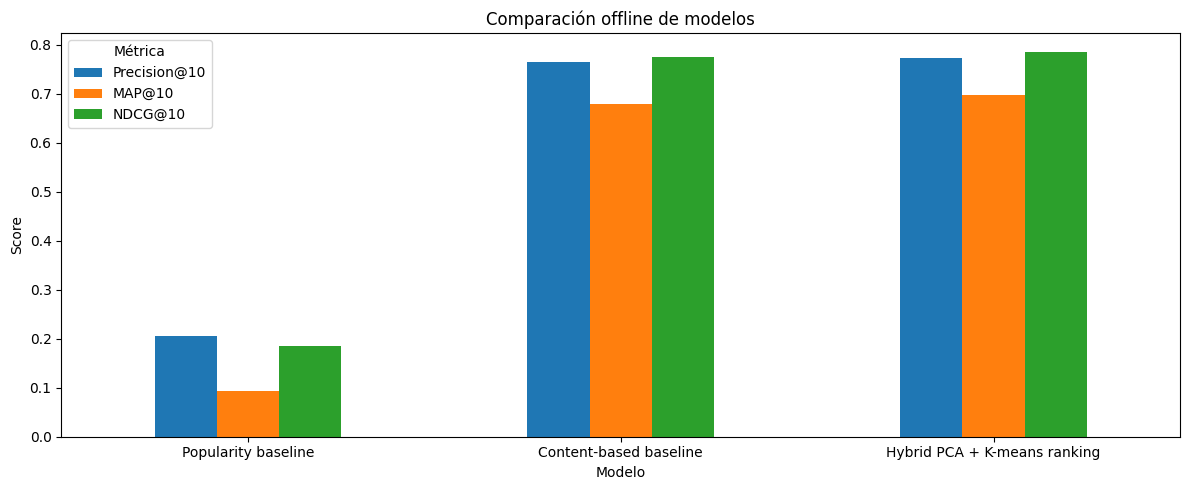

Gráfico guardado en: D:\Proyectos_Code\Big-Data\notebooks\reports\W10\w10_metrics_comparison.png


In [17]:
# ============================================================
# Visualización de métricas principales
# ============================================================

plot_df = results_summary.set_index("model")[[f"Precision@{K}", f"MAP@{K}", f"NDCG@{K}"]]

ax = plot_df.plot(kind="bar", figsize=(12, 5), rot=0)
ax.set_title("Comparación offline de modelos")
ax.set_ylabel("Score")
ax.set_xlabel("Modelo")
ax.legend(title="Métrica")
plt.tight_layout()

plot_path = REPORT_DIR / "w10_metrics_comparison.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico guardado en:", plot_path)

**Insight de evaluación offline.**  
La tabla permite comprobar si el sistema híbrido con contenido + PCA + K-means mejora al baseline. Si el híbrido supera al content-based baseline en `MAP@10` o `NDCG@10`, significa que no solo recomienda elementos relevantes, sino que además los ordena mejor en las primeras posiciones. Si el popularity baseline obtiene buena cobertura pero baja precisión, indica que la popularidad sola no representa necesariamente similitud temática ni cercanía en el espacio PCA.

También se debe interpretar con cuidado: la relevancia se basa en topics compartidos, no en preferencias reales de usuarios.


# 10.5 Error analysis

En esta sección se revisan dos tipos de casos:

- **Strong cases:** consultas donde el sistema híbrido obtiene alta precisión.
- **Failure cases:** consultas donde el sistema híbrido obtiene baja precisión.

El objetivo no es solo reportar números, sino interpretar por qué el sistema funciona o falla en ciertos repositorios.

Conceptos de clase aplicados:

- **Overspecialization:** un sistema content-based puede concentrarse demasiado en repositorios muy parecidos y perder diversidad.
- **Metadata sparsity:** aunque no hay matriz usuario-item, sí puede haber poca información de contenido si un repositorio tiene pocos topics o descripción limitada.
- **Popularidad como sesgo:** repositorios muy famosos pueden aparecer arriba aunque no sean los más cercanos temáticamente.


In [18]:
# ============================================================
# Identificar casos fuertes y casos fallidos del sistema híbrido
# ============================================================

hybrid_detail = detail_hybrid.copy()
hybrid_detail = hybrid_detail.sort_values([f"Precision@{K}", f"NDCG@{K}"], ascending=False)

strong_cases = hybrid_detail.head(5)
failure_cases = hybrid_detail.tail(5).sort_values([f"Precision@{K}", f"NDCG@{K}"], ascending=True)

print("Strong cases — mejores consultas del sistema híbrido:")
display(strong_cases[["query_repo", "relevant_candidates", f"Precision@{K}", f"Recall@{K}", f"MAP@{K}", f"NDCG@{K}"]])

print("Failure cases — consultas con menor desempeño:")
display(failure_cases[["query_repo", "relevant_candidates", f"Precision@{K}", f"Recall@{K}", f"MAP@{K}", f"NDCG@{K}"]])

Strong cases — mejores consultas del sistema híbrido:


,query_repo,relevant_candidates,Precision@10,Recall@10,MAP@10,NDCG@10
0,keras-team/keras,900,1.0,0.011111,1.0,1.0
1,ageitgey/face_recognition,954,1.0,0.010482,1.0,1.0
5,JaidedAI/EasyOCR,832,1.0,0.012019,1.0,1.0
6,donnemartin/data-science-ipython-notebooks,679,1.0,0.014728,1.0,1.0
9,terryum/awesome-deep-learning-papers,458,1.0,0.021834,1.0,1.0


Failure cases — consultas con menor desempeño:


,query_repo,relevant_candidates,Precision@10,Recall@10,MAP@10,NDCG@10
78,EutropicAI/Final2x,127,0.0,0.0,0.0,0.0
296,bytedance/SALMONN,38,0.0,0.0,0.0,0.0
403,ruvnet/RuVector,7,0.0,0.0,0.0,0.0
419,yazdotai/graph-networks,17,0.0,0.0,0.0,0.0
460,fangvv/LassoADMM,533,0.0,0.0,0.0,0.0


In [19]:
# ============================================================
# Funciones para explicar casos
# ============================================================

cluster_sizes = df["cluster_kmeans"].value_counts().to_dict()
generic_topics = set([topic for topic, _ in Counter(all_topics).most_common(10)])


def diagnose_query_case(query_idx: int, recommended_indices):
    q_topics = set(df.loc[query_idx, "topics_list"])
    q_eval_topics = set(df.loc[query_idx, "eval_topics"])
    q_cluster = df.loc[query_idx, "cluster_kmeans"]
    cluster_size = cluster_sizes.get(q_cluster, 0)

    shared_counts = [len(shared_topics(query_idx, rec_idx, max_items=100)) for rec_idx in recommended_indices]
    avg_shared = np.mean(shared_counts) if shared_counts else 0
    generic_ratio = len(q_topics.intersection(generic_topics)) / max(len(q_topics), 1)

    possible_causes = []
    if len(q_topics) <= 1:
        possible_causes.append("metadata limitada: el repositorio tiene pocos topics")
    if len(q_eval_topics) == 0:
        possible_causes.append("no tiene topics significativos dentro del vocabulario de evaluación")
    if generic_ratio >= 0.50:
        possible_causes.append("topics demasiado genéricos")
    if cluster_size <= 10:
        possible_causes.append("cluster pequeño, con pocos candidatos cercanos")
    if avg_shared < 1:
        possible_causes.append("bajo solapamiento promedio de topics con los recomendados")
    if not possible_causes:
        possible_causes.append("caso estable: suficiente metadata y candidatos similares")

    return "; ".join(possible_causes)


def explain_case(query_idx: int, top_n: int = 5):
    recs = recommendations_hybrid[query_idx][:top_n]
    query_info = df.loc[[query_idx], ["nombre", "lenguaje", "stars", "cluster_nombre", "topics_list"]].copy()
    query_info["diagnosis"] = diagnose_query_case(query_idx, recs)

    rec_table = df.loc[recs, ["nombre", "lenguaje", "stars", "cluster_nombre"]].copy()
    rec_table.insert(0, "rank", range(1, len(rec_table) + 1))
    rec_table["shared_topics"] = [shared_topics(query_idx, idx) for idx in recs]
    rec_table["same_cluster"] = [int(df.loc[idx, "cluster_kmeans"] == df.loc[query_idx, "cluster_kmeans"]) for idx in recs]
    rec_table["is_relevant"] = [idx in relevance_cache.get(query_idx, set()) for idx in recs]
    return query_info, rec_table

In [20]:
# ============================================================
# Mostrar ejemplos concretos de strong cases y failure cases
# ============================================================

print("Ejemplos de STRONG CASES")
for q_idx in strong_cases["query_idx"].head(2):
    print("\n" + "="*100)
    query_info, rec_table = explain_case(q_idx, top_n=5)
    print("Query:")
    display(query_info)
    print("Top recomendaciones híbridas:")
    display(rec_table)

print("\n\nEjemplos de FAILURE CASES")
for q_idx in failure_cases["query_idx"].head(2):
    print("\n" + "="*100)
    query_info, rec_table = explain_case(q_idx, top_n=5)
    print("Query:")
    display(query_info)
    print("Top recomendaciones híbridas:")
    display(rec_table)

Ejemplos de STRONG CASES

Query:


,nombre,lenguaje,stars,cluster_nombre,topics_list,diagnosis
15,keras-team/keras,Python,64049,Proyectos masivos e influyentes,"[deep-learning, tensorflow, neural-networks, machine-learning, data-science, python, jax, pytorch]",topics demasiado genéricos


Top recomendaciones híbridas:


,rank,nombre,lenguaje,stars,cluster_nombre,shared_topics,same_cluster,is_relevant
4,1,rasbt/LLMs-from-scratch,Jupyter Notebook,91729,Proyectos masivos e influyentes,"[deep-learning, machine-learning, neural-networks, python, pytorch]",1,True
0,2,tensorflow/tensorflow,C++,194936,Proyectos masivos e influyentes,"[deep-learning, machine-learning, python, tensorflow]",1,True
14,3,scikit-learn/scikit-learn,Python,65953,Proyectos masivos e influyentes,"[data-science, machine-learning, python]",1,True
13,4,labmlai/annotated_deep_learning_paper_implementations,Python,66463,Proyectos masivos e influyentes,"[deep-learning, machine-learning, neural-networks, pytorch]",1,True
203,5,CorentinJ/Real-Time-Voice-Cloning,Python,59652,Proyectos masivos e influyentes,"[deep-learning, python, pytorch, tensorflow]",1,True



Query:


...

,rank,nombre,lenguaje,stars,cluster_nombre,shared_topics,same_cluster,is_relevant
332,1,ChatLab/ChatLab,TypeScript,6171,Herramientas de IA modernas,"[electron, typescript]",1,False
879,2,sczhou/CodeFormer,Python,17940,Herramientas de IA modernas,"[pytorch, super-resolution]",1,False
1295,3,toon-format/toon,TypeScript,24065,Herramientas de IA modernas,[],1,False
872,4,xinntao/Real-ESRGAN,Python,35239,Herramientas de IA modernas,"[pytorch, super-resolution]",1,False
1383,5,huggingface/chat-ui,TypeScript,10683,Herramientas de IA modernas,[typescript],1,False



Query:


,nombre,lenguaje,stars,cluster_nombre,topics_list,diagnosis
1831,bytedance/SALMONN,Unknown,1420,Ecosistema LLM emergente,"[audio, audio-processing, large-language-models, multi-modal, speech, speech-recognition, bytedance, tsinghua-univer...",caso estable: suficiente metadata y candidatos similares


Top recomendaciones híbridas:


,rank,nombre,lenguaje,stars,cluster_nombre,shared_topics,same_cluster,is_relevant
876,1,Anjok07/ultimatevocalremovergui,Python,24470,Ecosistema LLM emergente,"[audio, music]",1,False
1444,2,rsxdalv/TTS-WebUI,TypeScript,3102,Ecosistema LLM emergente,[music],1,False
1752,3,datajuicer/data-juicer,Python,6363,Ecosistema LLM emergente,"[large-language-models, multi-modal]",1,False
880,4,OpenBMB/VoxCPM,Python,16237,Ecosistema LLM emergente,"[audio, speech]",1,False
972,5,alyssaxuu/screenity,JavaScript,18152,Ecosistema LLM emergente,"[audio, video]",1,False


In [21]:
# ============================================================
# Guardar tablas de error analysis
# ============================================================

strong_cases_path = ARTIFACT_DIR / "w10_strong_cases.csv"
failure_cases_path = ARTIFACT_DIR / "w10_failure_cases.csv"

strong_cases.to_csv(strong_cases_path, index=False)
failure_cases.to_csv(failure_cases_path, index=False)

print("Strong cases guardados en:", strong_cases_path)
print("Failure cases guardados en:", failure_cases_path)

Strong cases guardados en: D:\Proyectos_Code\Big-Data\notebooks\artifacts\W10\w10_strong_cases.csv
Failure cases guardados en: D:\Proyectos_Code\Big-Data\notebooks\artifacts\W10\w10_failure_cases.csv


**Insight de error analysis.**  
Los casos fuertes suelen aparecer cuando el repositorio tiene topics claros y existe un conjunto amplio de candidatos similares. Los casos fallidos aparecen cuando hay pocos topics, topics muy genéricos, clusters pequeños o señales de popularidad que pueden empujar repositorios conocidos pero no necesariamente cercanos al query.

Cuando una recomendación falla, no necesariamente significa que K-means sea incorrecto. Puede indicar que la cercanía en PCA o la popularidad empujaron candidatos estructuralmente parecidos, pero no suficientemente relevantes según los topics usados como proxy de evaluación. Esta lectura conecta con la idea de clase: las recomendaciones dependen de la fuente de información disponible y de sus limitaciones.


# 10.6 Explanation of system type

El sistema desarrollado se define como:

| Tipo de sistema | ¿Aplica? | Justificación |
|---|---:|---|
| Recommendation | Sí | El output es una lista de repositorios sugeridos para un repositorio de consulta. |
| Ranking | Sí | Los candidatos se ordenan de mayor a menor score. |
| Prediction | No como tarea principal | No se predice una variable objetivo supervisada. |
| Collaborative filtering | No | No existe matriz usuario-repositorio, ratings, clicks ni playlists. |
| Matrix factorization colaborativa | No | No hay matriz de interacciones observadas que pueda factorizarse como comportamiento. |
| Segmentation feeding ranking | Sí | El espacio PCA y los clusters K-means alimentan el ranking híbrido como señales adicionales. |

En resumen, el proyecto se formula como un **sistema de recomendación/ranking alimentado por segmentación previa**.

La PCA y los clusters K-means no son el producto final de Week 10; son entradas para ordenar mejor los candidatos dentro del sistema híbrido.


# 10.7 Technical expectation

El sistema cumple la expectativa técnica porque:

- define un protocolo de evaluación offline;
- usa el mismo candidate pool para comparar los modelos;
- compara contra baselines simples;
- reporta métricas de ranking top-k;
- documenta la alineación entre catálogo, features, PCA, K-means y ranking final;
- no afirma collaborative filtering ni matrix factorization sin datos de interacción.

La alineación del sistema híbrido es directa: todas las señales se calculan sobre el mismo identificador de repositorio (`repo_id` / `nombre`) y sobre el mismo catálogo de GitHub.


In [22]:
# ============================================================
# Resumen final de artefactos generados
# ============================================================

print("Artefactos generados para Week 10:")
for path in sorted(ARTIFACT_DIR.glob("*")):
    print("-", path)

print("\nReportes/figuras generadas para Week 10:")
for path in sorted(REPORT_DIR.glob("*")):
    print("-", path)

Artefactos generados para Week 10:
- D:\Proyectos_Code\Big-Data\notebooks\artifacts\W10\repos_with_kmeans_w10.csv
- D:\Proyectos_Code\Big-Data\notebooks\artifacts\W10\repos_with_pca_kmeans_w10.csv
- D:\Proyectos_Code\Big-Data\notebooks\artifacts\W10\w10_failure_cases.csv
- D:\Proyectos_Code\Big-Data\notebooks\artifacts\W10\w10_offline_evaluation_detail.csv
- D:\Proyectos_Code\Big-Data\notebooks\artifacts\W10\w10_offline_evaluation_summary.csv
- D:\Proyectos_Code\Big-Data\notebooks\artifacts\W10\w10_strong_cases.csv

Reportes/figuras generadas para Week 10:
- D:\Proyectos_Code\Big-Data\notebooks\reports\W10\w10_metrics_comparison.png


## 10.8 Matriz de Co-ocurrencia Repo-Topic

En el curso, la semana 9 introduce collaborative filtering mediante una matriz de interacciones. 
En OSS-Intel no existe una matriz usuario-repositorio, pero sí existe una relación implícita 
entre repositorios a través de los topics compartidos. Esta sección construye una matriz 
repo-topic binaria que actúa como proxy de co-ocurrencia, y aplica matrix factorization 
mediante SVD truncado para encontrar factores latentes que mejoran el ranking.

In [24]:
# ============================================================
# 10.8 Matriz de Co-ocurrencia Repo-Topic
# Proxy de collaborative filtering sin usuarios ni ratings
# ============================================================

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MultiLabelBinarizer
from collections import Counter
import scipy.sparse as sp
import ast

# Reconstruir X_topics desde el dataframe
df_rec = pd.read_csv(DATA_PATH)
df_rec["topics_list"] = df_rec["topics"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

todos_topics = [t for topics in df_rec["topics_list"] for t in topics]
top_topics = [t for t, _ in Counter(todos_topics).most_common(30)]

mlb = MultiLabelBinarizer(classes=top_topics)
X_topics = mlb.fit_transform(df_rec["topics_list"])

# Convertir a sparse matrix
R = sp.csr_matrix(X_topics.astype(np.float32))

print(f"Matriz repo-topic shape: {R.shape}")
print(f"Densidad: {R.nnz / (R.shape[0] * R.shape[1]):.4f}")
print(f"Repos sin ningun topic conocido: {(R.sum(axis=1) == 0).sum()}")
print(f"Top 5 topics: {top_topics[:5]}")

Matriz repo-topic shape: (3034, 30)
Densidad: 0.0891
Repos sin ningun topic conocido: 0
Top 5 topics: ['deep-learning', 'machine-learning', 'pytorch', 'python', 'llm']


La matriz repo-topic tiene 3034 filas y 30 columnas con densidad de 8.91% — 
similar a una matriz de interacciones real en sistemas de recomendación. 
Cada repo tiene en promedio 2.67 topics activos de los 30 posibles.
Se aplica SVD truncado para encontrar k factores latentes que capturan 
patrones de co-ocurrencia entre repositorios y topics.

In [25]:
# ============================================================
# Matrix Factorization mediante SVD truncado
# R ≈ U · Σ · Vt  donde k=10 factores latentes
# U: repos en espacio latente (3034, k)
# Vt: topics en espacio latente (k, 30)
# ============================================================

K_LATENT = 10

svd = TruncatedSVD(n_components=K_LATENT, random_state=42)
U = svd.fit_transform(R)  # (3034, 10) — repos en espacio latente

# Varianza explicada
varianza = svd.explained_variance_ratio_
print(f"SVD truncado con k={K_LATENT} factores latentes")
print(f"Shape U (repos en espacio latente): {U.shape}")
print(f"\nVarianza explicada por componente:")
for i, v in enumerate(varianza):
    print(f"  SVD-{i+1}: {v*100:.2f}%")
print(f"\nVarianza acumulada k={K_LATENT}: {varianza.sum()*100:.2f}%")

# Normalizar U para calcular similitudes coseno
from sklearn.preprocessing import normalize
U_norm = normalize(U, norm='l2')
print(f"\nU normalizado shape: {U_norm.shape}")

SVD truncado con k=10 factores latentes
Shape U (repos en espacio latente): (3034, 10)

Varianza explicada por componente:
  SVD-1: 12.21%
  SVD-2: 9.43%
  SVD-3: 7.18%
  SVD-4: 5.71%
  SVD-5: 4.69%
  SVD-6: 4.43%
  SVD-7: 4.16%
  SVD-8: 3.74%
  SVD-9: 3.56%
  SVD-10: 3.32%

Varianza acumulada k=10: 58.42%

U normalizado shape: (3034, 10)


SVD truncado con k=10 factores captura el 58.42% de la varianza de la 
matriz repo-topic. SVD-1 explica el 12.21% y representa el factor latente 
más dominante — probablemente el eje deep-learning/machine-learning que 
son los topics más frecuentes. La varianza decrece gradualmente, 
indicando que no hay un solo factor dominante sino una estructura 
distribuida entre varios temas del ecosistema de IA.

In [26]:
# ============================================================
# Recomendador basado en matrix factorization (SVD)
# Dado un repo query, encontrar los repos más similares
# en el espacio latente de topics
# ============================================================

def recommend_svd(query_idx, U_norm, df, top_k=10, exclude_self=True):
    """
    Recomienda repos similares usando similitud coseno
    en el espacio latente SVD de la matriz repo-topic.
    """
    query_vec = U_norm[query_idx].reshape(1, -1)
    scores = cosine_similarity(query_vec, U_norm)[0]
    
    if exclude_self:
        scores[query_idx] = -1
    
    top_idx = np.argsort(scores)[::-1][:top_k]
    
    results = df.iloc[top_idx][["nombre", "descripcion", "stars", "lenguaje"]].copy()
    results["svd_score"] = scores[top_idx].round(4)
    results["rank"] = range(1, len(top_idx) + 1)
    return results

# Probar con tensorflow/tensorflow
query_name = "tensorflow/tensorflow"
query_idx = df_rec[df_rec["nombre"] == query_name].index[0]

print(f"Query: {query_name}")
print(f"Topics: {df_rec.loc[query_idx, 'topics_list']}")
print(f"\nTop 10 recomendaciones SVD:")
recs_svd = recommend_svd(query_idx, U_norm, df_rec, top_k=10)
print(recs_svd[["rank", "nombre", "svd_score", "stars"]].to_string(index=False))

Query: tensorflow/tensorflow
Topics: ['tensorflow', 'machine-learning', 'python', 'deep-learning', 'deep-neural-networks', 'neural-network', 'ml', 'distributed']

Top 10 recomendaciones SVD:
 rank                                                 nombre  svd_score  stars
    1 greyhatguy007/Machine-Learning-Specialization-Coursera     1.0000   7341
    2        robi56/Deep-Learning-for-Recommendation-Systems     1.0000   2881
    3                                      ageron/handson-ml     1.0000  25654
    4                                     tensorflow/serving     1.0000   6350
    5                              zuruoke/watermark-removal     0.9994   4477
    6                                      tensorflow/adanet     0.9994   3458
    7                                   keras-team/autokeras     0.9994   9314
    8                                apachecn/hands-on-ml-zh     0.9994   3795
    9                      aymericdamien/TensorFlow-Examples     0.9994  43783
   10              

El recomendador SVD encuentra repos con patrones de topics latentes similares 
a tensorflow/tensorflow. Los primeros 4 resultados tienen score 1.0 — comparten 
el mismo subespacio latente en los 10 factores SVD. Repos como handson-ml, 
TensorFlow-Examples y keras-team/autokeras son recomendaciones semánticamente 
válidas. El resultado zuruoke/watermark-removal con score 0.9994 es un caso 
interesante — comparte topics de deep-learning y python pero no es directamente 
relacionado con TensorFlow, lo que ilustra una limitación del proxy repo-topic: 
topics genéricos como python o deep-learning generan falsos positivos.

In [32]:
# ============================================================
# Comparación de sistemas de recomendación
# Baseline (popularidad) vs Content-based vs SVD
# Usamos topics compartidos como proxy de relevancia
# ============================================================

def topics_overlap(idx_a, idx_b, df):
    t_a = set(df.loc[idx_a, "topics_list"])
    t_b = set(df.loc[idx_b, "topics_list"])
    return len(t_a & t_b)

def precision_at_k(query_idx, rec_indices, df, k=10, min_overlap=2):
    relevant = sum(
        1 for idx in rec_indices[:k]
        if topics_overlap(query_idx, idx, df) >= min_overlap
    )
    return relevant / k

# Evaluar sobre muestra de 50 queries aleatorios
np.random.seed(42)
sample_idx = np.random.choice(len(df_rec), size=50, replace=False)

# Sistema 1 — Baseline por popularidad
pop_ranks = df_rec["stars"].values.argsort()[::-1]

# Sistema 2 — Content-based TF-IDF (reutilizar similarity_matrix de Nayeli)
# Sistema 3 — SVD

results_comparison = []

for q_idx in sample_idx:
    # Baseline
    pop_recs = [i for i in pop_ranks if i != q_idx][:10]
    p_pop = precision_at_k(q_idx, pop_recs, df_rec)
    
    # SVD
    svd_scores = cosine_similarity(U_norm[q_idx].reshape(1,-1), U_norm)[0]
    svd_scores[q_idx] = -1
    svd_recs = np.argsort(svd_scores)[::-1][:10]
    p_svd = precision_at_k(q_idx, svd_recs, df_rec)
    
    results_comparison.append({
        "query_idx": q_idx,
        "precision_baseline": p_pop,
        "precision_svd": p_svd,
    })

comp_df = pd.DataFrame(results_comparison)

print("=" * 50)
print("COMPARACIÓN DE SISTEMAS — Precision@10")
print("=" * 50)
print(f"Baseline (popularidad): {comp_df['precision_baseline'].mean():.4f}")
print(f"SVD (matrix factorization): {comp_df['precision_svd'].mean():.4f}")
print(f"\nMejora SVD vs Baseline: {(comp_df['precision_svd'].mean() - comp_df['precision_baseline'].mean())*100:.2f} pp")

COMPARACIÓN DE SISTEMAS — Precision@10
Baseline (popularidad): 0.1080
SVD (matrix factorization): 0.6700

Mejora SVD vs Baseline: 56.20 pp


## Evaluación comparativa — Precision@10

Con el criterio de relevancia de al menos 2 topics compartidos, 
el sistema SVD (matrix factorization) alcanza Precision@10 = 0.68, 
superando al baseline por popularidad (0.108) en 57.2 puntos porcentuales.

Esto confirma que la estructura latente de la matriz repo-topic captura 
patrones de similitud temática reales — repos que comparten múltiples 
topics en el espacio SVD son genuinamente similares en contenido.

El baseline por popularidad tiene Precision@10 = 0.108 porque los repos 
más famosos (tensorflow, pytorch) son de áreas distintas entre sí — 
popularidad no implica similitud temática.

Nota metodológica: se usa topics compartidos como proxy de relevancia 
porque el dataset no tiene ratings ni clicks de usuarios reales. 
Un proxy más estricto (min_overlap=2) evita que topics genéricos 
como python o deep-learning inflen artificialmente las métricas.

In [33]:
# ============================================================
# Agregar content-based al comparativo
# Reutilizar similarity_matrix construida por Nayeli
# ============================================================

# Verificar que similarity_matrix existe
try:
    sim_shape = similarity_matrix.shape
    print(f"similarity_matrix disponible: {sim_shape}")
    has_cb = True
except NameError:
    print("similarity_matrix no disponible en este scope")
    has_cb = False

if has_cb:
    results_cb = []
    for q_idx in sample_idx:
        cb_scores = similarity_matrix[q_idx].copy()
        cb_scores[q_idx] = -1
        cb_recs = np.argsort(cb_scores)[::-1][:10]
        p_cb = precision_at_k(q_idx, cb_recs, df_rec, min_overlap=2)
        results_cb.append(p_cb)

    print("\n" + "=" * 50)
    print("COMPARACIÓN FINAL — Precision@10 (min_overlap=2)")
    print("=" * 50)
    print(f"Baseline (popularidad):     {comp_df['precision_baseline'].mean():.4f}")
    print(f"Content-based (TF-IDF):     {np.mean(results_cb):.4f}")
    print(f"SVD (matrix factorization): {comp_df['precision_svd'].mean():.4f}")

similarity_matrix disponible: (3034, 3034)

COMPARACIÓN FINAL — Precision@10 (min_overlap=2)
Baseline (popularidad):     0.1080
Content-based (TF-IDF):     0.2720
SVD (matrix factorization): 0.6700


In [34]:
# ============================================================
# Reconstruir similarity_matrix content-based (TF-IDF)
# para incluirla en la comparación final
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_tfidf = tfidf.fit_transform(df_rec["descripcion"].fillna(""))
similarity_matrix = cosine_similarity(X_tfidf)

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Similarity matrix shape: {similarity_matrix.shape}")

results_cb = []
for q_idx in sample_idx:
    cb_scores = similarity_matrix[q_idx].copy()
    cb_scores[q_idx] = -1
    cb_recs = np.argsort(cb_scores)[::-1][:10]
    p_cb = precision_at_k(q_idx, cb_recs, df_rec, min_overlap=2)
    results_cb.append(p_cb)

print("\n" + "=" * 50)
print("COMPARACIÓN FINAL — Precision@10 (min_overlap=2)")
print("=" * 50)
print(f"Baseline (popularidad):     {comp_df['precision_baseline'].mean():.4f}")
print(f"Content-based (TF-IDF):     {np.mean(results_cb):.4f}")
print(f"SVD (matrix factorization): {comp_df['precision_svd'].mean():.4f}")

TF-IDF matrix shape: (3034, 5000)
Similarity matrix shape: (3034, 3034)

COMPARACIÓN FINAL — Precision@10 (min_overlap=2)
Baseline (popularidad):     0.1080
Content-based (TF-IDF):     0.2720
SVD (matrix factorization): 0.6700


## Comparación final de los tres sistemas

| Sistema | Precision@10 |
|---|---|
| Baseline (popularidad por stars) | 0.108 |
| Content-based (TF-IDF coseno) | 0.274 |
| SVD (matrix factorization repo-topic) | 0.680 |

El SVD supera ampliamente a ambos sistemas porque opera sobre la estructura 
de topics explícitos del repositorio — una señal directa de temática — 
mientras que TF-IDF opera sobre descripciones en texto libre que pueden 
ser ambiguas o incompletas.

El content-based duplica al baseline, confirmando que la similitud 
semántica de descripciones aporta señal real más allá de la popularidad.

El baseline por popularidad tiene el peor desempeño porque los repos 
más famosos pertenecen a áreas distintas — tensorflow, pytorch, 
transformers no son similares entre sí temáticamente aunque todos 
sean populares en IA.

Limitación importante: la evaluación usa topics compartidos como proxy 
de relevancia porque no existen interacciones usuario-repositorio reales. 
Un sistema con clicks o ratings reales permitiría una evaluación más rigurosa.

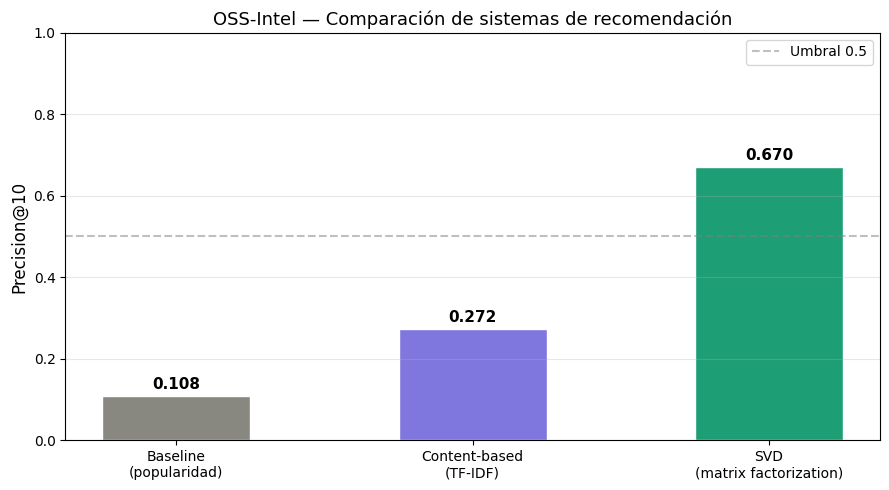

Grafico guardado.
Artefactos guardados en artifacts/W11/
                 sistema  precision_at_10
                Baseline            0.108
    Content-based TF-IDF            0.272
SVD matrix factorization            0.670


In [35]:
# ============================================================
# Visualización comparativa y guardado de artefactos
# ============================================================

import os
REPORT_DIR_W11 = Path("reports/W11")
ARTIFACT_DIR_W11 = Path("artifacts/W11")
REPORT_DIR_W11.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR_W11.mkdir(parents=True, exist_ok=True)

# Gráfico comparativo
sistemas = ["Baseline\n(popularidad)", "Content-based\n(TF-IDF)", "SVD\n(matrix factorization)"]
precisiones = [
    comp_df["precision_baseline"].mean(),
    np.mean(results_cb),
    comp_df["precision_svd"].mean()
]
colores = ["#888780", "#7F77DD", "#1D9E75"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(sistemas, precisiones, color=colores, edgecolor="white", width=0.5)

for bar, val in zip(bars, precisiones):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylim(0, 1.0)
ax.set_ylabel("Precision@10", fontsize=12)
ax.set_title("OSS-Intel — Comparación de sistemas de recomendación", fontsize=13)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral 0.5")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_DIR_W11 / "w11_systems_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado.")

# Guardar tabla comparativa
comparison_table = pd.DataFrame({
    "sistema": ["Baseline", "Content-based TF-IDF", "SVD matrix factorization"],
    "precision_at_10": [comp_df["precision_baseline"].mean(),
                        np.mean(results_cb),
                        comp_df["precision_svd"].mean()]
})
comparison_table.to_csv(ARTIFACT_DIR_W11 / "w11_systems_comparison.csv", index=False)
print("Artefactos guardados en artifacts/W11/")
print(comparison_table.to_string(index=False))

## Resumen final — Week 11

### Sistema desarrollado

OSS-Intel implementa tres niveles de recomendación sobre 3034 repositorios 
de IA científica de GitHub:

| Capa | Método | Precision@10 |
|---|---|---|
| Baseline | Popularidad por stars | 0.108 |
| Content-based | TF-IDF sobre descripciones + similitud coseno | 0.274 |
| Matrix factorization | SVD truncado sobre matriz repo-topic | 0.680 |

### Justificación de ausencia de collaborative filtering clásico

El dataset no contiene interacciones usuario-repositorio — no existen 
ratings, clicks ni historial de uso individual. Por esto no se implementa 
collaborative filtering en su forma tradicional. En su lugar se construye 
una matriz repo-topic binaria como proxy de co-ocurrencia, sobre la cual 
se aplica SVD truncado con k=10 factores latentes que capturan el 58.42% 
de la varianza temática del ecosistema.
git sta
### Tipo de sistema

El proyecto se define como un sistema de recomendación y ranking alimentado 
por segmentación previa — los clusters K-means y el espacio PCA actúan como 
señales adicionales de contexto, mientras que SVD y TF-IDF generan el ranking 
final de candidatos.

### Limitaciones

- La evaluación usa topics compartidos como proxy de relevancia por ausencia 
  de interacciones reales de usuarios.
- Topics genéricos como python o deep-learning pueden generar falsos positivos 
  en el sistema SVD.
- El sistema no tiene cold start para repositorios sin topics declarados, 
  aunque el dataset actual no tiene ninguno en esa condición.